In [26]:
%cd /Users/debasmitroy/Desktop/programming/research/debasmit-ut-research/ITML-quest/

/Users/debasmitroy/Desktop/programming/research/debasmit-ut-research/ITML-quest


In [10]:
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from sentence_transformers import SentenceTransformer
from torchvision.models import ViT_B_16_Weights, vit_b_16
from tqdm import tqdm

# Configuration

In [9]:
DATA_ROOT = Path("data/caltech_101_low/train")
SEED = 42
TRAIN_PER_CLASS = 5
TEST_PER_CLASS = 2
IMAGE_BATCH_SIZE = 16
TEXT_BATCH_SIZE = 64
EXCLUDED_CLASSES = {"BACKGROUND_Google"}

# Utility

In [12]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def get_device():
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

def l2_normalize(x, eps=1e-12):
    return x / np.clip(np.linalg.norm(x, axis=1, keepdims=True), eps, None)

def clean_class_name(name):
    return name.replace("_", " ").strip().lower()

## Dataset

In [13]:
class CaltechSmallDataset:
    IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

    def __init__(self, root, train_per_class=5, test_per_class=2, seed=42):
        self.root = Path(root)
        self.train_per_class = train_per_class
        self.test_per_class = test_per_class
        self.seed = seed
        self.class_names = []
        self.train_paths = []
        self.train_labels = []
        self.test_paths = []
        self.test_labels = []
        self._prepare()

    def _prepare(self):
        if not self.root.exists():
            raise FileNotFoundError(f"Dataset not found: {self.root.resolve()}")

        class_dirs = [
            p for p in sorted(self.root.iterdir())
            if p.is_dir() and p.name not in EXCLUDED_CLASSES
        ]

        rng = random.Random(self.seed)
        required = self.train_per_class + self.test_per_class

        for class_dir in class_dirs:
            files = [
                f for f in sorted(class_dir.iterdir())
                if f.is_file() and f.suffix.lower() in self.IMAGE_EXTENSIONS
            ]

            if len(files) < required:
                print(f"Skipping {class_dir.name}: only {len(files)} images")
                continue

            rng.shuffle(files)
            class_id = len(self.class_names)
            self.class_names.append(class_dir.name)

            train_files = files[:self.train_per_class]
            test_files = files[self.train_per_class:required]

            for path in train_files:
                self.train_paths.append(path)
                self.train_labels.append(class_id)

            for path in test_files:
                self.test_paths.append(path)
                self.test_labels.append(class_id)

        self.train_labels = np.asarray(self.train_labels)
        self.test_labels = np.asarray(self.test_labels)

        print(f"\nClasses: {len(self.class_names)}")
        print(f"CSA fitting images: {len(self.train_paths)}")
        print(f"Test images: {len(self.test_paths)}")

    def make_training_texts(self):
        templates = [
            "a photo of a {}",
            "an image of a {}",
            "a picture of a {}",
            "a photograph of a {}",
            "this is a photo of a {}",
        ]
        texts = []
        for i, class_id in enumerate(self.train_labels):
            name = clean_class_name(self.class_names[int(class_id)])
            texts.append(templates[i % len(templates)].format(name))
        return texts


In [18]:
def create_text_prototypes(class_names, text_encoder, csa):
    templates = [
        "a photo of a {}",
        "an image of a {}",
        "a picture of a {}",
        "a photograph of a {}",
        "this is an image of a {}",
    ]

    texts = []
    owners = []

    for class_id, class_name in enumerate(class_names):
        name = clean_class_name(class_name)
        for template in templates:
            texts.append(template.format(name))
            owners.append(class_id)

    text_features = text_encoder.encode(texts)
    text_canonical = csa.transform_texts(text_features)
    owners = np.asarray(owners)

    prototypes = [
        text_canonical[owners == class_id].mean(axis=0)
        for class_id in range(len(class_names))
    ]
    return np.stack(prototypes)


## Image Encoder

In [14]:
class ViTImageEncoder:
    def __init__(self, device, batch_size=16):
        self.device = device
        self.batch_size = batch_size
        weights = ViT_B_16_Weights.DEFAULT
        self.preprocess = weights.transforms()
        self.model = vit_b_16(weights=weights)
        self.model.heads = torch.nn.Identity()
        self.model.eval().to(device)
        for p in self.model.parameters():
            p.requires_grad_(False)
        self.output_dim = 768

    @torch.inference_mode()
    def encode(self, image_paths):
        all_features = []

        for start in tqdm(
            range(0, len(image_paths), self.batch_size),
            desc="Encoding images"
        ):
            batch_paths = image_paths[start:start + self.batch_size]
            batch = torch.stack([
                self.preprocess(Image.open(path).convert("RGB"))
                for path in batch_paths
            ]).to(self.device)

            features = self.model(batch).cpu().numpy()
            all_features.append(features)

        features = np.concatenate(all_features, axis=0).astype(np.float64)
        return l2_normalize(features)


## Text Encoder

In [15]:
class MiniLMTextEncoder:
    def __init__(
        self,
        device,
        model_name="sentence-transformers/all-MiniLM-L6-v2",
        batch_size=64
    ):
        self.batch_size = batch_size
        self.model = SentenceTransformer(model_name, device=device)

    def encode(self, texts):
        features = self.model.encode(
            list(texts),
            batch_size=self.batch_size,
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=True
        )
        return features.astype(np.float64)



## CSA

In [17]:
@dataclass
class CSAConfig:
    regularization: float = 1e-3
    max_components: int = 64
    correlation_threshold: float = 0.20
    s: Optional[int] = None

class CSA:
    def __init__(self, config):
        self.config = config
        self.image_mean = None
        self.text_mean = None
        self.A = None
        self.B = None
        self.rho = None
        self.s = None

    @staticmethod
    def inverse_sqrt_psd(matrix, eps=1e-10):
        values, vectors = np.linalg.eigh(matrix)
        values = np.clip(values, eps, None)
        return vectors @ np.diag(1.0 / np.sqrt(values)) @ vectors.T

    def fit(self, image_features, text_features):
        if image_features.shape[0] != text_features.shape[0]:
            raise ValueError("Image and text feature counts must match.")

        N = image_features.shape[0]
        self.image_mean = image_features.mean(axis=0, keepdims=True)
        self.text_mean = text_features.mean(axis=0, keepdims=True)

        X = image_features - self.image_mean
        Y = text_features - self.text_mean

        Cxx = (X.T @ X) / (N - 1)
        Cyy = (Y.T @ Y) / (N - 1)
        Cxy = (X.T @ Y) / (N - 1)

        reg = self.config.regularization
        Cxx += reg * np.eye(Cxx.shape[0])
        Cyy += reg * np.eye(Cyy.shape[0])

        Wx = self.inverse_sqrt_psd(Cxx)
        Wy = self.inverse_sqrt_psd(Cyy)

        P = Wx @ Cxy @ Wy
        U, singular_values, Vt = np.linalg.svd(P, full_matrices=False)

        r = min(
            self.config.max_components,
            N - 1,
            image_features.shape[1],
            text_features.shape[1]
        )

        U = U[:, :r]
        V = Vt.T[:, :r]

        self.A = Wx @ U
        self.B = Wy @ V
        self.rho = np.clip(singular_values[:r], 0.0, 1.0)

        if self.config.s is not None:
            self.s = int(np.clip(self.config.s, 1, r))
        else:
            self.s = max(1, int(np.sum(
                self.rho >= self.config.correlation_threshold
            )))

        print(f"\nCSA fitted on {N} pairs")
        print(f"Canonical rank: {r}")
        print(f"Selected s: {self.s}")
        print("First 10 rho:", np.round(self.rho[:10], 4))
        return self

    def transform_images(self, features):
        return (features - self.image_mean) @ self.A

    def transform_texts(self, features):
        return (features - self.text_mean) @ self.B

    def similarity_matrix(self, image_canonical, text_canonical, s=None):
        s = self.s if s is None else min(int(s), len(self.rho))
        X = l2_normalize(image_canonical[:, :s])
        Y = l2_normalize(text_canonical[:, :s])
        return (X * self.rho[:s][None, :]) @ Y.T

    def paired_similarity(self, image_features, text_features, s=None):
        s = self.s if s is None else min(int(s), len(self.rho))
        X = l2_normalize(self.transform_images(image_features)[:, :s])
        Y = l2_normalize(self.transform_texts(text_features)[:, :s])
        return np.sum(X * Y * self.rho[:s][None, :], axis=1)

## Evaluation

In [19]:
def evaluate_classification(similarity, labels):
    pred = np.argmax(similarity, axis=1)
    top1 = np.mean(pred == labels)

    top5_idx = np.argsort(similarity, axis=1)[:, -5:]
    top5 = np.mean([
        label in guesses
        for label, guesses in zip(labels, top5_idx)
    ])
    return float(top1), float(top5)

def evaluate_matched_vs_shuffled(csa, image_features, text_features):
    matched = csa.paired_similarity(image_features, text_features)

    rng = np.random.default_rng(SEED)
    perm = rng.permutation(len(text_features))
    perm = np.roll(perm, 1)

    shuffled = csa.paired_similarity(
        image_features,
        text_features[perm]
    )
    return matched, shuffled

In [20]:
def plot_rho(rho, selected_s):
    x = np.arange(1, len(rho) + 1)
    plt.figure(figsize=(7, 4))
    plt.plot(x, rho, marker="o")
    plt.axvline(selected_s, linestyle="--", label=f"s={selected_s}")
    plt.xlabel("Canonical dimension")
    plt.ylabel(r"$\rho_i$")
    plt.title("CSA Canonical Correlations")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_matched_vs_shuffled(matched, shuffled):
    plt.figure(figsize=(7, 4))
    plt.hist(matched, bins=30, alpha=0.5, label="Matched")
    plt.hist(shuffled, bins=30, alpha=0.5, label="Shuffled")
    plt.xlabel("CSA similarity")
    plt.ylabel("Count")
    plt.title("Matched vs Shuffled Pairs")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Trigger

In [24]:
seed_everything(SEED)
device = get_device()
print(f"Device: {device}")

Device: mps


In [27]:
dataset = CaltechSmallDataset(
        DATA_ROOT,
        train_per_class=TRAIN_PER_CLASS,
        test_per_class=TEST_PER_CLASS,
        seed=SEED
    )



Classes: 101
CSA fitting images: 505
Test images: 202


In [ ]:
train_texts = dataset.make_training_texts()

In [33]:
print(f"Training texts: {len(train_texts)}")
print(f"Training images: {len(dataset.train_paths)}")
print(f"Test images: {len(dataset.test_paths)}")
print(f"Classes: {len(dataset.class_names)}")
print(f"First 5 training texts: {train_texts[:5]}")

Training texts: 505
Training images: 505
Test images: 202
Classes: 101
First 5 training texts: ['a photo of a faces', 'an image of a faces', 'a picture of a faces', 'a photograph of a faces', 'this is a photo of a faces']


In [36]:
image_encoder = ViTImageEncoder(
        device=device,
        batch_size=IMAGE_BATCH_SIZE
    )
text_encoder = MiniLMTextEncoder(
    device=device,
    batch_size=TEXT_BATCH_SIZE
)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /Users/debasmitroy/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:18<00:00, 18.7MB/s] 
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 18806.08it/s]


In [37]:
print("\nEncoding CSA fitting images...")
image_train_features = image_encoder.encode(dataset.train_paths)


Encoding CSA fitting images...


Encoding images: 100%|██████████| 32/32 [00:10<00:00,  2.99it/s]


In [38]:
print("\nEncoding CSA fitting text...")
text_train_features = text_encoder.encode(train_texts)


Encoding CSA fitting text...


Batches: 100%|██████████| 8/8 [00:00<00:00, 14.71it/s]


In [42]:
print("\nFeature shapes")
print("Image:", image_train_features.shape)
print("Text :", text_train_features.shape)


Feature shapes
Image: (505, 768)
Text : (505, 384)


In [49]:
csa = CSA(CSAConfig(
        regularization=1e-3,
        max_components=min(image_train_features.shape[0], text_train_features.shape[0]),
        correlation_threshold=0.70,
        s=None
    ))
csa.fit(image_train_features, text_train_features)


CSA fitted on 505 pairs
Canonical rank: 384
Selected s: 54
First 10 rho: [0.9252 0.9097 0.8998 0.8924 0.8904 0.8856 0.881  0.8776 0.8745 0.87  ]


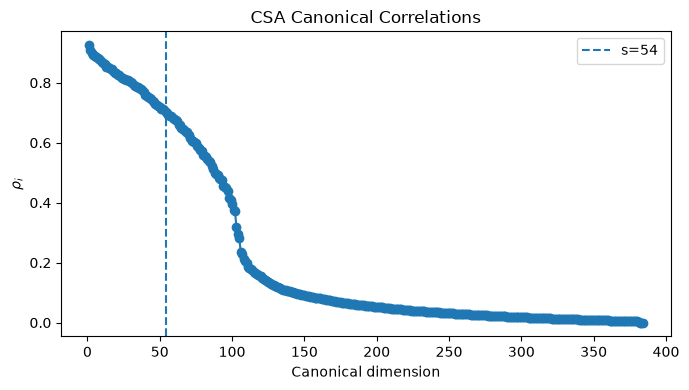

In [50]:
plot_rho(csa.rho, csa.s)


Matched mean : 0.7805
Shuffled mean: -0.0008


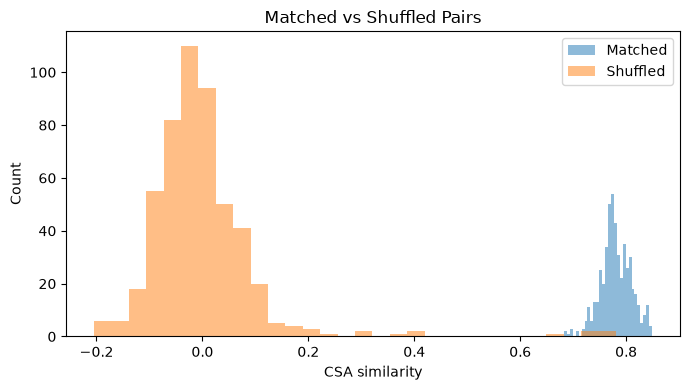

In [51]:
matched, shuffled = evaluate_matched_vs_shuffled(
        csa,
        image_train_features,
        text_train_features
    )

print("\nMatched mean :", round(float(matched.mean()), 4))
print("Shuffled mean:", round(float(shuffled.mean()), 4))
plot_matched_vs_shuffled(matched, shuffled)

In [53]:
print("\nEncoding test images...")
image_test_features = image_encoder.encode(dataset.test_paths)
image_test_canonical = csa.transform_images(image_test_features)


Encoding test images...


Encoding images: 100%|██████████| 13/13 [00:03<00:00,  3.39it/s]


In [54]:
print("\nCreating class text prototypes...")
class_text_canonical = create_text_prototypes(
    dataset.class_names,
    text_encoder,
    csa
)


Creating class text prototypes...


Batches: 100%|██████████| 8/8 [00:00<00:00, 23.97it/s]


In [55]:
scores = csa.similarity_matrix(
        image_test_canonical,
        class_text_canonical
    )

In [56]:
top1, top5 = evaluate_classification(
        scores,
        dataset.test_labels
    )

In [58]:
print("\n===== CALTECH-101 CSA RESULTS =====")
print(f"Classes: {len(dataset.class_names)}")
print(f"CSA fitting pairs: {len(dataset.train_paths)}")
print(f"Test images: {len(dataset.test_paths)}")
print(f"Selected s: {csa.s}")
print(f"Top-1 accuracy: {top1 * 100:.2f}%")
print(f"Top-5 accuracy: {top5 * 100:.2f}%")


===== CALTECH-101 CSA RESULTS =====
Classes: 101
CSA fitting pairs: 505
Test images: 202
Selected s: 54
Top-1 accuracy: 82.18%
Top-5 accuracy: 97.52%



Sensitivity to s
s= 1 | Top-1=  1.98% | Top-5=  8.91%
s= 2 | Top-1=  5.94% | Top-5= 33.66%
s= 4 | Top-1= 40.59% | Top-5= 76.73%
s= 8 | Top-1= 64.85% | Top-5= 90.10%
s=16 | Top-1= 78.71% | Top-5= 94.06%
s=32 | Top-1= 82.67% | Top-5= 95.54%
s=64 | Top-1= 82.18% | Top-5= 98.51%


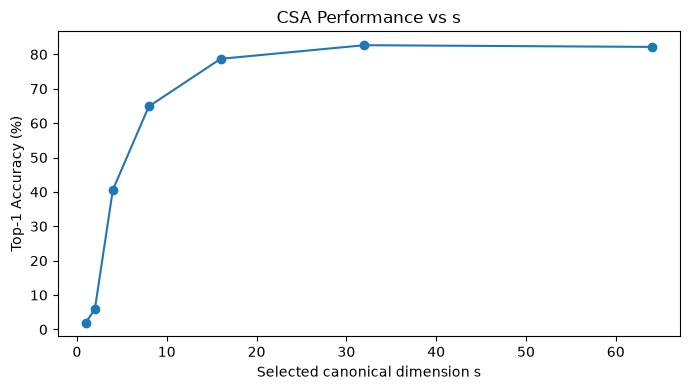

In [59]:
print("\nSensitivity to s")
candidate_s = [1, 2, 4, 8, 16, 32, 64]
candidate_s = [s for s in candidate_s if s <= len(csa.rho)]

s_values = []
accuracies = []

for s in candidate_s:
    scores_s = csa.similarity_matrix(
        image_test_canonical,
        class_text_canonical,
        s=s
    )
    top1_s, top5_s = evaluate_classification(
        scores_s,
        dataset.test_labels
    )
    s_values.append(s)
    accuracies.append(top1_s)

    print(
        f"s={s:2d} | "
        f"Top-1={top1_s * 100:6.2f}% | "
        f"Top-5={top5_s * 100:6.2f}%"
    )

plt.figure(figsize=(7, 4))
plt.plot(s_values, np.asarray(accuracies) * 100, marker="o")
plt.xlabel("Selected canonical dimension s")
plt.ylabel("Top-1 Accuracy (%)")
plt.title("CSA Performance vs s")
plt.tight_layout()
plt.show()

predictions = np.argmax(scores, axis=1)

In [60]:
print("\nExample predictions")
for i in range(min(20, len(dataset.test_paths))):
    true_id = int(dataset.test_labels[i])
    pred_id = int(predictions[i])

    print(
        f"{dataset.test_paths[i].name:18s} | "
        f"true={dataset.class_names[true_id]:18s} | "
        f"pred={dataset.class_names[pred_id]}"
    )


Example predictions
image_0092.jpg     | true=Faces              | pred=Faces
image_0317.jpg     | true=Faces              | pred=Faces
image_0345.jpg     | true=Faces_easy         | pred=Faces
image_0386.jpg     | true=Faces_easy         | pred=Faces
image_0167.jpg     | true=Leopards           | pred=Leopards
image_0030.jpg     | true=Leopards           | pred=Leopards
image_0677.jpg     | true=Motorbikes         | pred=Motorbikes
image_0497.jpg     | true=Motorbikes         | pred=Motorbikes
image_0018.jpg     | true=accordion          | pred=accordion
image_0039.jpg     | true=accordion          | pred=accordion
image_0339.jpg     | true=airplanes          | pred=airplanes
image_0308.jpg     | true=airplanes          | pred=airplanes
image_0030.jpg     | true=anchor             | pred=chair
image_0041.jpg     | true=anchor             | pred=ant
image_0042.jpg     | true=ant                | pred=ant
image_0014.jpg     | true=ant                | pred=ant
image_0026.jpg     | true